In [1]:
import wandb
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.pyplot import cm
import re
import math
import matplotlib.gridspec as gridspec
import json
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

api = wandb.Api(timeout=19)

/home/mila/r/roy.eyono/inhibitory-normalization/.venv/lib/python3.9/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/mila/r/roy.eyono/inhibitory-normalization/.venv/lib/python3.9/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by as

In [2]:
# Fetch runs for a specific project
def fetch_runs(api, entity, project_name, filters, order=None):
    if order:
        runs = api.runs(f"{entity}/{project_name}", filters=filters, order=order)
    else:
        runs = api.runs(f"{entity}/{project_name}", filters=filters)
    #print(f"Runs for project '{project_name}':")
    return runs

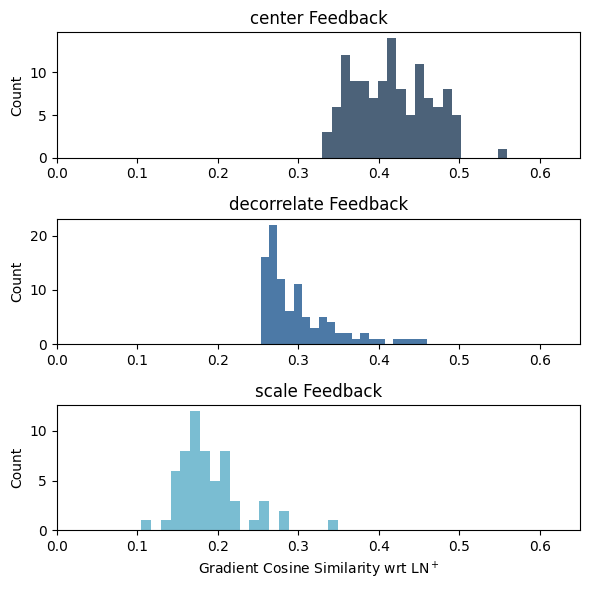

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm, colors

# -------------------------
# Helpers
# -------------------------

def truncate_colormap(cmap, minval=0.0, maxval=0.85, n=100):
    return colors.LinearSegmentedColormap.from_list(
        f"trunc({cmap.name},{minval:.2f},{maxval:.2f})",
        cmap(np.linspace(minval, maxval, n))
    )

def safe_float(x):
    try:
        v = float(x)
        if np.isnan(v):
            return None
        return v
    except Exception:
        return None

brightness_factors = [0, 0.25, 0.5, 0.75]
ln_feedback_types = ['center', 'decorrelate', 'scale']
layers_to_average = ["fc0", "fc1"]

# Colormap
trunc_ocean = truncate_colormap(cm.get_cmap("ocean"), 0.25, 0.75)
colors_ocean = [trunc_ocean(i / (len(ln_feedback_types) - 1))
                for i in range(len(ln_feedback_types))]


# -------------------------
# Data collection
# -------------------------

def collect_grad_alignment(ln_fdb):
    """Collect last-epoch gradient summary values for this LN-feedback type."""
    collected = []

    for bright in brightness_factors:
        runs = fetch_runs(
            api,
            entity="project_danns",
            project_name="Luminosity_LNHomeostasis",
            filters={
                "config.dataset": "fashionmnist",
                "config.brightness_factor": bright,
                "config.homeostasis": 1,
                "config.normtype": 0,
                "config.normtype_detach": 0,
                "config.excitation_training": 1,
                "config.layer_norm": None,
                "config.feedback_alignment": 0,
                "config.ln_feedback": ln_fdb,
                "config.use_testset": True,
                "config.lambda_homeo": 0.01,
            },
            order="-summary_metrics.test_acc"
        )

        for run in runs:
            vals = []
            for layer in layers_to_average:
                key = f"gradient_alignment_{layer}"
                if key not in run.summary:
                    continue
                v = safe_float(run.summary[key])
                if v is not None:
                    vals.append(v)

            if vals:
                collected.append(np.mean(vals))

    return np.array(collected)


# Collect all data
data_dict = {ln_fdb: collect_grad_alignment(ln_fdb)
             for ln_fdb in ln_feedback_types}


# -------------------------
# Plotting — 3 vertical panels
# -------------------------

fig, axes = plt.subplots(3, 1, figsize=(6, 6), sharex=False)

for idx, ln_fdb in enumerate(ln_feedback_types):
    ax = axes[idx]
    values = data_dict[ln_fdb]

    if len(values) == 0:
        ax.set_title(f"{ln_fdb} (no data)")
        continue

    ax.hist(
        values,
        bins=20,
        alpha=0.7,
        color=colors_ocean[idx]
    )

    ax.set_ylabel("Count")
    ax.set_title(f"{ln_fdb} Feedback")
    # ax.set_yscale("log")
    ax.set_xlim(0, 0.65)  # restrict to cosine similarity range

axes[-1].set_xlabel("Gradient Cosine Similarity wrt LN$^+$")

plt.tight_layout()
plt.show()


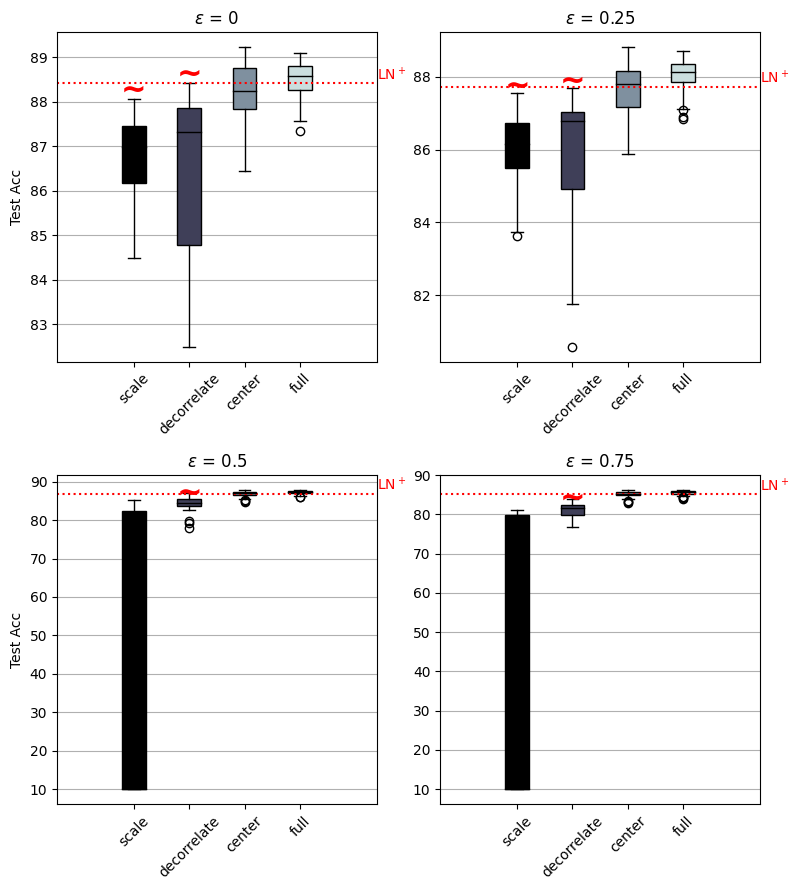

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib import cm, colors
from scipy.stats import mannwhitneyu

# ---- Configs ----
brightness_factors = [0, 0.25, 0.5, 0.75]
feedback_types = ['scale', 'decorrelate', 'center', 'full']
bar_width = 0.18
outlier_threshold = 15
median_threshold = 60
indicator_symbol = "~"

def significance_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "n.s."

results = {}

# ---- Colormap: Truncated 'bone' ----
def truncate_colormap(cmap, minval=0.0, maxval=0.85, n=100):
    return colors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )

trunc_bone = truncate_colormap(cm.get_cmap('bone'), 0.0, 0.85)
feedback_colors = {f: trunc_bone(i / (len(feedback_types) - 1)) for i, f in enumerate(feedback_types)}

# ---- Fetch Accuracy Data ----
acc_data = {b: {f: [] for f in feedback_types} for b in brightness_factors}

for bfi in brightness_factors:
    ln_acc_data = {b: [] for b in brightness_factors}
    runs_e_network_ln = fetch_runs(api, entity='project_danns', project_name='Luminosity_LNHomeostasis', filters={"config.dataset": "fashionmnist", 
                                                            "config.brightness_factor": bfi, "config.homeostasis": 0, "config.normtype": 0, "config.normtype_detach": 0,
                                                            "config.excitation_training": 1, "config.layer_norm": 1, "config.use_testset": True}, order="-summary_metrics.test_acc")

    for run in runs_e_network_ln:
        acc = run.summary.get("test_acc", 0.1)
        ln_acc_data[bfi].append(acc)

    for ln_fdb in feedback_types:
        runs = fetch_runs(
            api,
            entity='project_danns',
            project_name='Luminosity_LNHomeostasis',
            filters={
                "config.dataset": "fashionmnist",
                "config.brightness_factor": bfi,
                "config.homeostasis": 1,
                "config.normtype": 0,
                "config.normtype_detach": 0,
                "config.excitation_training": 1,
                "config.layer_norm": None,
                "config.feedback_alignment": 0,
                "config.ln_feedback": ln_fdb,
                "config.use_testset": True,
                "config.lambda_homeo": 0.01,
            },
            order="-summary_metrics.test_acc"
        )
        for run in runs:
            acc = run.summary.get("test_acc", 0.1)
            acc_data[bfi][ln_fdb].append(acc)

        U, p = mannwhitneyu(acc_data[bfi][ln_fdb], ln_acc_data[bfi], alternative="two-sided")
        if bfi in results:
            results[bfi].append((ln_fdb, U, p, significance_stars(p)))
        else:
            results[bfi] = [(ln_fdb, U, p, significance_stars(p))]

# ---- Plotting ----
fig, axs = plt.subplots(2, 2, figsize=(9, 9), sharey=False)
axs = axs.flatten()  # Flatten 2D array for easier indexing
center_offset = (len(feedback_types) - 1) / 2
offset_spacing = 2  # increase for more spacing
offsets = {f: (i - center_offset) * bar_width * offset_spacing for i, f in enumerate(feedback_types)}


for idx, bfi in enumerate(brightness_factors):
    ax = axs[idx]
    x_base = 0
    all_medians = []

    # Get median accuracy for LN and noLN here:

    runs_e_network_ln = fetch_runs(api, entity='project_danns', project_name='Luminosity_LNHomeostasis', filters={"config.dataset": "fashionmnist", 
                                                            "config.brightness_factor": bfi, "config.homeostasis": 0, "config.normtype": 0, "config.normtype_detach": 0,
                                                            "config.excitation_training": 1, "config.layer_norm": 1, "config.use_testset": True}, order="-summary_metrics.test_acc")
    top_n = len(runs_e_network_ln)

    runs_e_network_ln_acc = []

    for top in range(top_n):
        runs_e_network_ln_acc.append(runs_e_network_ln[top].summary['test_acc'])
    runs_e_network_ln_acc = np.median(runs_e_network_ln_acc)


    for ln_fdb in feedback_types:
        raw_data = acc_data[bfi][ln_fdb]
        if not raw_data:
            continue

        position = x_base + offsets[ln_fdb]
        full_data = np.array(raw_data)
        median = np.median(full_data)
        all_medians.append(median)

        data = full_data
        filtered = False

        if median >= 50:
            extreme_outliers = full_data <= 10
            if np.any(extreme_outliers):
                data = full_data[~extreme_outliers]
                filtered = True

        if len(data) == 0:
            continue  # skip empty box

        ax.boxplot(
            [data],
            positions=[position],
            widths=bar_width * 0.85,
            patch_artist=True,
            boxprops=dict(facecolor=feedback_colors[ln_fdb]),
            medianprops=dict(color='black'),
            showfliers=True
        )

        if filtered:
            max_val = max(data)
            indicator_y = max_val + 0.2
            ax.text(
                position,
                indicator_y,
                indicator_symbol,
                ha='center',
                va='center',
                fontsize=22,
                fontweight='bold',
                color='red'
            )

    ax.axhline(y=runs_e_network_ln_acc, color='red', linestyle='dotted')
    x_max = ax.get_xlim()[1]
    ax.text(x=x_max, y=runs_e_network_ln_acc, s='LN$^+$', va='bottom', ha='left', color='red')
    # ax.axhline(y=runs_ei_network_noln_acc, color='red', linestyle='dotted')
    ax.set_xticks([x_base + offsets[f] for f in feedback_types])
    ax.set_xticklabels(feedback_types, rotation=45)
    ax.set_title(f"$\epsilon$ = {bfi}")
    if idx %2 == 0:
        ax.set_ylabel("Test Acc")
    ax.grid(axis='y', which='both')

plt.tight_layout()
plt.subplots_adjust(right=0.85)

In [5]:
for bf in [0, 0.25, 0.5, 0.75]:
    print(results[bf])

[('scale', 19.0, 1.7765155176935156e-10, '***'), ('decorrelate', 58.5, 7.420849423851919e-09, '***'), ('center', 376.5, 0.2803902784140948, 'n.s.'), ('full', 548.5, 0.14729414015608025, 'n.s.')]
[('scale', 15.0, 1.0129195113609678e-10, '***'), ('decorrelate', 46.0, 2.391990123971441e-09, '***'), ('center', 473.0, 0.7393709037526534, 'n.s.'), ('full', 645.0, 0.00402634598736044, '**')]
[('scale', 0.0, 1.7859665457534555e-11, '***'), ('decorrelate', 19.5, 1.9835544938650151e-10, '***'), ('center', 490.5, 0.5542293058399959, 'n.s.'), ('full', 648.0, 0.0034966117583866427, '**')]
[('scale', 0.0, 1.2684120418235963e-11, '***'), ('decorrelate', 1.0, 3.0928254574223854e-11, '***'), ('center', 474.0, 0.7282290320145953, 'n.s.'), ('full', 656.5, 0.0023163530335524977, '**')]
